<b style="font-size:3rem;">Exploratory Data Aanalysis</b>

<b style="font-size:2rem;">Loading Modules</b>

In [840]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bokeh.plotting import figure
from bokeh.io import output_file, show
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import bs4
df = pd.read_csv("Hotel Bookings (Dirty).csv")


<b style="font-size:2rem;">General Information of Dataset</b>

In [841]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [842]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


<b style="font-size:2rem;">Number of missing data in each column</b>
<p style="font-size:1.7rem;">The column "company" has too much missing value (about 95% of rows miss this value).But the valid rows are still worth of information. For example bookings through companies, might have high cancellation rate which might indicate the inefficiency of companies in booking process, or vice versa. The same is true for the column "agent".</p>
<p style="font-size:1.7rem;">The empty rows in the "country" column, seems to be required in the application form and the missing values are an error. The same is true for the "children" column. Since the number of their occurances are little and we have enough data, we can simply drop them.</p>

In [843]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [844]:
df.drop(df[(df["children"].isnull()) | (df["country"].isnull())].index,inplace=True)
print(f"missing values in children column: {df["children"].isnull().sum()}")
print(f"missing values in country column: {df["country"].isnull().sum()}")

missing values in children column: 0
missing values in country column: 0


<b style="font-size:2rem;">Duplicate rows</b>
<p style="font-size:1.7rem;">Note that the probability of two customers having the exact reservation specs in the same day is very low but not zero. So duplicate rows are worth of information and shall not be removed.</p>

<b style="font-size:2rem;">Converting To Numerical</b>
<p style="font-size:1.7rem;">We have to convert strings and non-numerical values to numerical values so that learning algorithms are able to process them. To do this we iterate through non-numerical values and allocate a uniqure number (equal or greater than 0) to each unqiue value.</p>
<p style="font-size:1.7rem;">Note that columns "agent" and "company" contain null or undefined values, and we should replace them with a numerical value. Since the minimum value for both columns are greater than zero, we could simply replace them with zero.</p>

In [845]:
non_numerical_cols = df.select_dtypes(include=["object"]).columns

for col in non_numerical_cols:
    if len(df[col].unique()) > 3:
        print(f"{col}: categorical encoded")
        df[col] = df[col].astype('category').cat.codes
    else:
        print(f"{col}: one-hot encoded")
        encoded_df = pd.get_dummies(df[col],dtype='int64')
        df[encoded_df.columns] = encoded_df
        df.drop(col, axis=1, inplace=True)

df.loc[df["agent"].isnull(),"agent"] = 0.0
df.loc[df["company"].isnull(),"company"] = 0.0

df.info()
df.isnull().sum()

hotel: one-hot encoded
arrival_date_month: categorical encoded
meal: categorical encoded
country: categorical encoded
market_segment: categorical encoded
distribution_channel: categorical encoded
reserved_room_type: categorical encoded
assigned_room_type: categorical encoded
deposit_type: one-hot encoded
customer_type: categorical encoded
reservation_status: one-hot encoded
reservation_status_date: categorical encoded
<class 'pandas.core.frame.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     118898 non-null  int64  
 1   lead_time                       118898 non-null  int64  
 2   arrival_date_year               118898 non-null  int64  
 3   arrival_date_month              118898 non-null  int8   
 4   arrival_date_week_number        118898 non-null  int64  
 5   arrival_date_day_of_month       1

is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

<b style="font-size:2rem;">Normalization</b>
<p style="font-size:1.7rem;">We use min-max normalization for all the columns since there are columns with binary values already present in the dataset.</p>
<p style="font-size:1.7rem;">Note that we could have also used scaling. Eitherway, if our future algorithm requires to have a scaling, we could do just that.</p>

In [846]:
scaler = MinMaxScaler()

# We keep an unnormalized version for later use
ndf = df.copy(deep=True)
ndf[df.columns] = scaler.fit_transform(df[df.columns])
ndf.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,total_of_special_requests,reservation_status_date,City Hotel,Resort Hotel,No Deposit,Non Refund,Refundable,Canceled,Check-Out,No-Show
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,...,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000
mean,0.371352,0.141535,0.578828,0.499131,0.503203,0.493363,0.058056,0.061028,0.033789,0.010421,...,0.114337,0.558977,0.666975,0.333025,0.876070,0.122567,0.001363,0.361234,0.628648,0.010118
std,0.483168,0.145052,0.353729,0.321362,0.261346,0.292677,0.062264,0.046346,0.010520,0.039917,...,0.158536,0.246004,0.471297,0.471297,0.329503,0.327941,0.036887,0.480360,0.483168,0.100078
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.024423,0.500000,0.181818,0.288462,0.233333,0.000000,0.024390,0.036364,0.000000,...,0.000000,0.364324,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.093623,0.500000,0.545455,0.519231,0.500000,0.062500,0.048780,0.036364,0.000000,...,0.000000,0.567568,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,0.218453,1.000000,0.727273,0.711538,0.733333,0.125000,0.073171,0.036364,0.000000,...,0.200000,0.767568,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<b style="font-size:2rem;">Correlation Analysis</b>
<p style="font-size:1.7rem;">We see that "reservation status" fields that had the value "Canceled" before categorization, is very much correlated with "is canceled" field, which is expected. However they are not 100% identical. Denoting that there are mismatches between them which is probably an error. This means that we can safely drop one of the columns. But since the "Canceled" column is a one hot column, it is best to drop the "is canceled" column.</p>
<p style="font-size:1.7rem;">The correlation between "reservation status date" is also highly correlated with "arrival date year" but this barely has anything to do with reservation. Instead it is an indicator that the confirmation of reservation has been greatly delayed in some cases or it was around the turn of the year.</p>

In [847]:
corr = ndf.corr()
corr.style.background_gradient(cmap='coolwarm')

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,City Hotel,Resort Hotel,No Deposit,Non Refund,Refundable,Canceled,Check-Out,No-Show
is_canceled,1.000000,0.291994,0.016412,-0.001745,0.007465,-0.006127,-0.002631,0.024110,0.058381,0.004751,-0.032521,-0.018657,0.270225,0.056948,0.165539,-0.085179,0.109922,-0.055493,-0.062230,-0.175880,-0.144659,-0.046543,-0.082306,0.054016,-0.068768,0.046199,-0.194796,-0.235643,-0.162965,0.133964,-0.133964,-0.477791,0.481349,-0.011401,0.978440,-1.000000,0.131542
lead_time,0.291994,1.000000,0.039924,0.086126,0.126738,0.002320,0.083984,0.164783,0.116799,-0.038335,-0.021149,-0.000648,0.054327,0.009220,0.217012,-0.125091,0.085961,-0.071128,-0.107036,-0.171187,0.000004,-0.013353,-0.083375,0.170007,0.072846,-0.066381,-0.115561,-0.096536,-0.067664,0.071867,-0.071867,-0.379789,0.379741,0.016512,0.302960,-0.291994,-0.044442
arrival_date_year,0.016412,0.039924,1.000000,-0.251447,-0.540493,-0.000590,0.021669,0.031754,0.029146,0.054492,-0.013183,0.065335,-0.153267,0.107001,0.020912,0.010128,-0.119922,0.029800,0.092999,0.036661,0.031124,0.056169,0.035028,-0.056823,-0.006000,0.197857,-0.012661,0.108927,0.897806,0.033765,-0.033765,0.065921,-0.066143,-0.000819,0.017242,-0.016412,-0.003523
arrival_date_month,-0.001745,0.086126,-0.251447,1.000000,0.301967,-0.018136,-0.032010,-0.026019,-0.058890,-0.082961,-0.012203,-0.062464,0.026656,-0.051836,-0.021192,-0.002049,0.040267,-0.003386,-0.062569,-0.037398,-0.017963,-0.041306,0.029376,0.048464,0.011897,-0.109569,-0.019368,-0.052959,-0.171728,0.035517,-0.035517,-0.067091,0.065404,0.017838,-0.000081,0.001745,-0.008036
arrival_date_week_number,0.007465,0.126738,-0.540493,0.301967,1.000000,0.066839,0.017642,0.015007,0.025394,0.005494,0.010039,-0.017623,0.025984,-0.001011,0.005258,-0.030411,0.035367,-0.020768,-0.008544,-0.005064,0.005187,-0.018204,-0.033047,0.022993,-0.028728,0.075277,0.001717,0.025778,-0.212450,0.000730,-0.000730,-0.005441,0.007373,-0.016945,0.012479,-0.007465,-0.023854
arrival_date_day_of_month,-0.006127,0.002320,-0.000590,-0.018136,0.066839,1.000000,-0.015920,-0.027608,-0.001837,0.014562,-0.000539,-0.007229,-0.000613,-0.004183,0.001640,-0.006340,-0.027013,0.000118,0.017143,0.012054,0.010767,0.000427,0.004041,0.022737,0.012195,0.029923,0.008262,0.003082,0.032062,-0.002104,0.002104,0.005073,-0.008720,0.032207,-0.008999,0.006127,0.013616
stays_in_weekend_nights,-0.002631,0.083984,0.021669,-0.032010,0.017642,-0.015920,1.000000,0.494888,0.090410,0.045430,0.018396,0.044637,-0.128054,0.114059,0.091167,-0.087836,-0.013008,-0.040597,0.141700,0.087755,0.062401,0.161999,-0.078028,-0.054568,-0.110190,0.047300,-0.018147,0.071669,0.045525,-0.189729,0.189729,0.114283,-0.115020,0.001721,-0.006224,0.002631,0.017170
stays_in_week_nights,0.024110,0.164783,0.031754,-0.026019,0.015007,-0.027608,0.494888,1.000000,0.091999,0.044259,0.020157,0.035776,-0.121237,0.107874,0.085842,-0.097994,-0.014274,-0.047367,0.168662,0.102137,0.095665,0.196584,-0.041187,-0.002161,-0.128539,0.063628,-0.024378,0.066785,0.036693,-0.237769,0.237769,0.079875,-0.081020,0.006798,0.022971,-0.024110,0.006144
adults,0.058381,0.116799,0.029146,-0.058890,0.025394,-0.001837,0.090410,0.091999,1.000000,0.029590,0.017887,0.025500,-0.108308,0.204186,0.173667,-0.147494,-0.006974,-0.105028,0.211998,0.148282,-0.052420,0.024014,-0.162244,-0.008765,-0.102810,0.227480,0.016370,0.121815,0.025574,-0.017771,0.017771,0.029973,-0.030468,0.003129,0.065823,-0.058381,-0.034083
children,0.004751,-0.038335,0.054492,-0.082961,0.005494,0.014562,0.045430,0.044259,0.029590,1.000000,0.024131,-0.050307,-0.0

In [848]:
df.drop(["is_canceled"],axis=1,inplace=True)

<b style="font-size:3rem;">Visualization</b>
<b style="font-size:2rem;display: block;margin-top: 1rem;">Reservation Status</b>
<p style="font-size:1.7rem;">A suitable chart to show the final status of each reservation is pie chart.</p>
<p style="font-size:1.7rem;">A good chunk of the reservations have been checked out, a smaller portion have been canceled and a very samll percetange of them havn't showed up. The result are quite reasonable.</p>

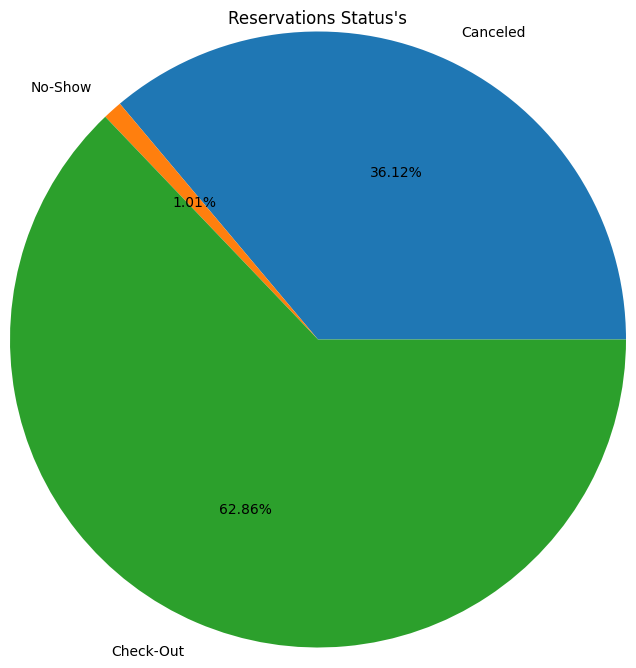

In [849]:
labels = ["Canceled","No-Show","Check-Out"]
reservations = [df[df["Canceled"] == 1.0]["Canceled"].sum(),df[df["No-Show"] == 1.0]["No-Show"].sum(),df[df["Check-Out"] == 1.0]["Check-Out"].sum()]
plt.figure(figsize=(10,8))
plt.pie(reservations,labels=labels,autopct='%1.2f%%',radius=1.25)
plt.title("Reservations Status's")
plt.show()

<b style="font-size:2rem;">Number Of Staying Nights</b>
<p style="font-size:1.7rem;">We can use box plot to gain a general understanding of how many days a customer might want to stay in the hotel.</p>


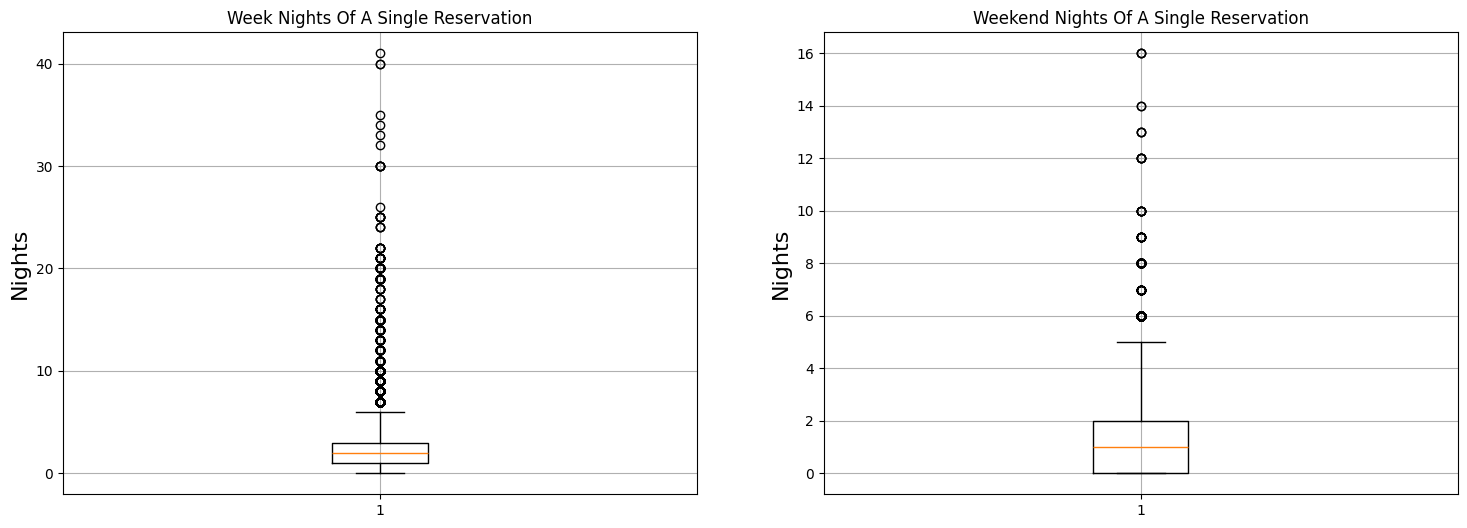

In [ ]:
# Create the histogram
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
plt.boxplot(df["stays_in_week_nights"],vert=True)
plt.ylabel('Nights',fontsize=16)
plt.title("Week Nights Of A Single Reservation")
plt.grid()

plt.subplot(1,2,2)
plt.boxplot(df["stays_in_weekend_nights"])
plt.title("Weekend Nights Of A Single Reservation")
plt.ylabel('Nights',fontsize=16)
plt.grid()

plt.show()

<b style="font-size:2rem;">Reservations Over Time</b>
<p style="font-size:1.7rem;">Another good analysis is the amount of each reservation status in each year.</p>

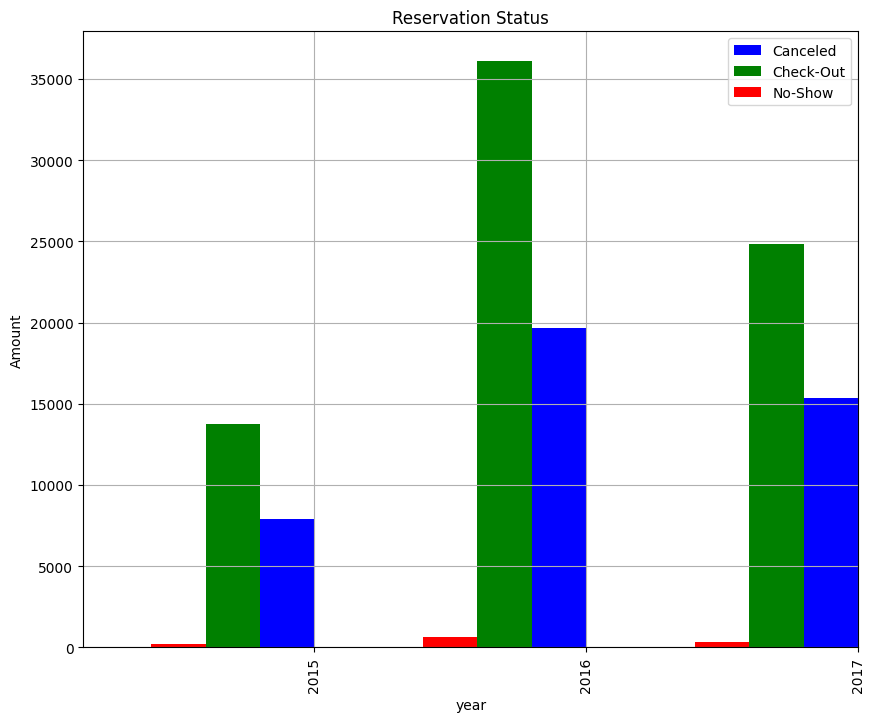

In [851]:
years = [year for year in df["arrival_date_year"].unique()]

cancelations_per_year = pd.DataFrame(data={
    "year": years,
    "Canceled": [ df[df["arrival_date_year"] == year]["Canceled"].sum() for year in years]
})

no_shows_per_year = pd.DataFrame(data={
    "year": years,
    "No-Show": [ df[df["arrival_date_year"] == year]["No-Show"].sum() for year in years]
})

check_outs_per_year = pd.DataFrame(data={
    "year": years,
    "Check-Out": [ df[df["arrival_date_year"] == year]["Check-Out"].sum() for year in years]
})

ax = cancelations_per_year.plot.bar(x="year",color="blue",position=1,width=.2,figsize=(10,8))
check_outs_per_year.plot.bar(x="year",color="green",position=2,width=.2,ax=ax)
no_shows_per_year.plot.bar(x="year",color="red",position=3,width=.2,ax=ax)

plt.title("Reservation Status")
plt.ylabel("Amount")
plt.grid()
plt.show()


<p style="font-size:1.7rem;">Let's see the reservations through out the year 2016.</p>

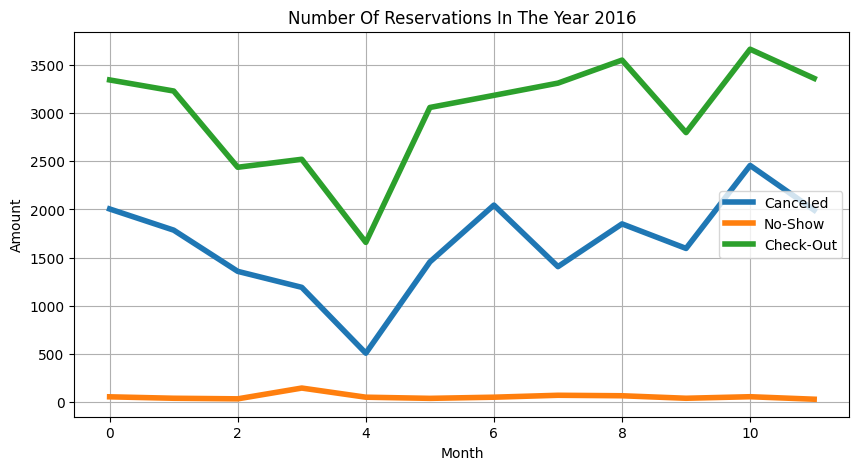

In [852]:
year = 2016
months = [month for month in df["arrival_date_month"].unique()]

cancelations_per_month = pd.DataFrame(data={
    "month": months,
    "Canceled": [ df[(df["arrival_date_month"] == month) & (df["arrival_date_year"] == year)]["Canceled"].sum() for month in months]
}).sort_values(by="month",ascending=True)

no_shows_per_month = pd.DataFrame(data={
    "month": months,
    "No-Show": [ df[(df["arrival_date_month"] == month) & (df["arrival_date_year"] == year)]["No-Show"].sum() for month in months]
}).sort_values(by="month",ascending=True)

check_outs_per_month = pd.DataFrame(data={
    "month": months,
    "Check-Out": [ df[(df["arrival_date_month"] == month) & (df["arrival_date_year"] == year)]["Check-Out"].sum() for month in months]
}).sort_values(by="month",ascending=True)

ax = cancelations_per_month.plot.line(x='month',figsize=(10,5),lw=4)
no_shows_per_month.plot.line(x='month',figsize=(10,5),lw=4,ax=ax)
check_outs_per_month.plot.line(x='month',figsize=(10,5),lw=4,ax=ax)

plt.title("Number Of Reservations In The Year 2016")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid()
plt.show()

<b style="font-size:3rem;">Feature Engineering</b>
<p style="font-size:1.7rem;">We can combine the "stays in week nights" and "stays in weekend nights" to get the total duration of stay.</p>
<p style="font-size:1.7rem;">The same can be done for columns</p>


In [853]:
# Get the total duration of stay
df["stay_nights"] = df.apply(lambda x: x["stays_in_week_nights"] + x["stays_in_weekend_nights"],axis=1)

# Get the total number of guests
df["guests"] = df.apply(lambda x: x["adults"]+x["children"]+x["babies"],axis=1)

df[["stays_in_week_nights","stays_in_weekend_nights","stay_nights","babies","children","adults","guests"]][20:31]

,stays_in_week_nights,stays_in_weekend_nights,stay_nights,babies,children,adults,guests
20,4,1,5.0,0,0.0,1,1.0
21,4,2,6.0,0,0.0,2,2.0
22,4,2,6.0,0,0.0,2,2.0
23,4,2,6.0,0,0.0,2,2.0
24,5,2,7.0,0,0.0,2,2.0
25,5,2,7.0,0,0.0,2,2.0
26,5,2,7.0,0,0.0,2,2.0
27,5,2,7.0,0,0.0,2,2.0
28,5,2,7.0,0,0.0,2,2.0
29,5,2,7.0,0,0.0,2,2.0


<p style="font-size:1.7rem;">An interesting analysis would be to see what is the average daily expences for each country.</p>

In [854]:
df["avg_nationality_adr"] = df["adr"].groupby(df["country"]).transform("mean")
df[["country","avg_nationality_adr"]].head(20)

,country,avg_nationality_adr
0,135,92.046622
1,135,92.046622
2,59,96.022058
3,59,96.022058
4,59,96.022058
5,59,96.022058
6,135,92.046622
7,135,92.046622
8,135,92.046622
9,135,92.046622


<p style="font-size:1.7rem;">We can go a step further and apply target encoding to the newly created column.</p>

In [855]:
df["avg_nationality_adr_enc"] = df["avg_nationality_adr"].astype("category").cat.codes
df[["country","avg_nationality_adr_enc"]].head(20)

,country,avg_nationality_adr_enc
0,135,27
1,135,27
2,59,34
3,59,34
4,59,34
5,59,34
6,135,27
7,135,27
8,135,27
9,135,27


<b style="font-size:2rem;">Feature Selection Using Mutual Information</b>

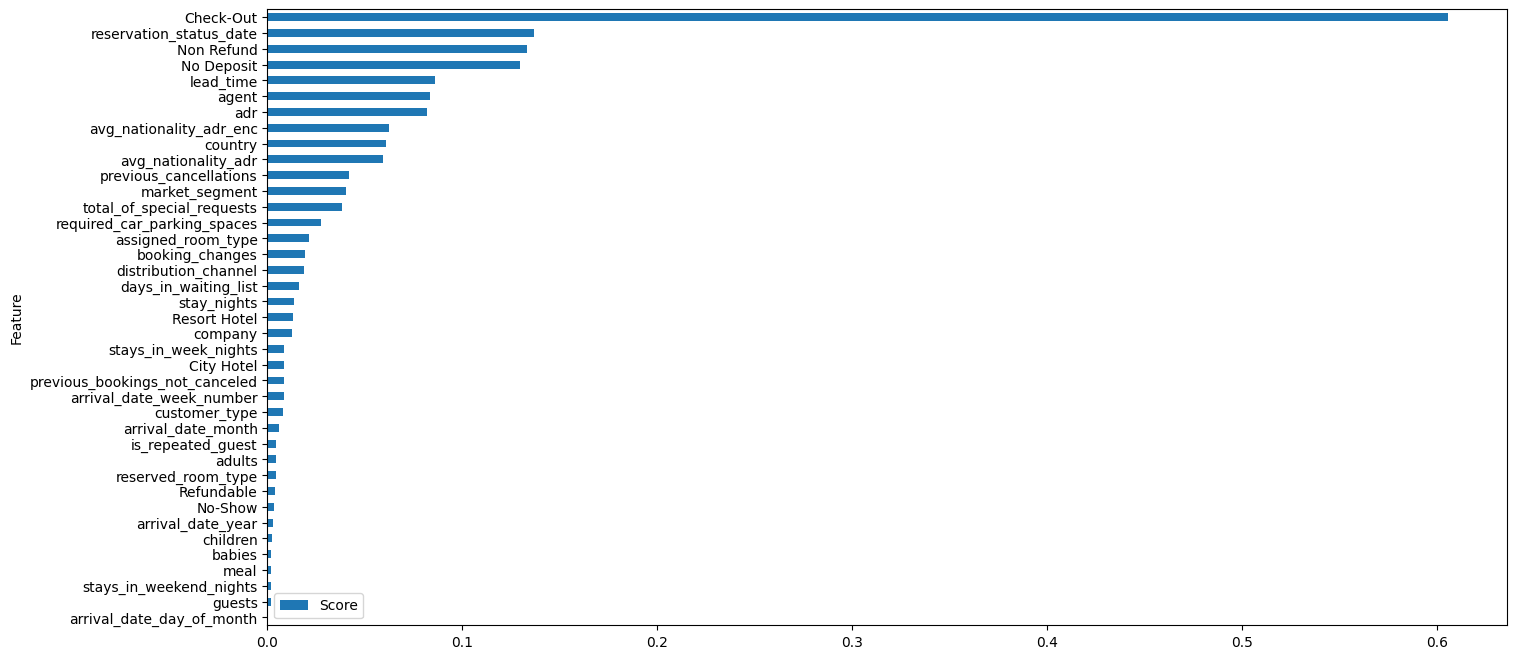

In [856]:
pdf = df.copy(True)
target_column = pdf.pop("Canceled")

feature_selector = SelectKBest(score_func=mutual_info_regression, k = 'all').fit(pdf,target_column)

feature_scores = pd.DataFrame({'Feature':pdf.columns,'Score':feature_selector.scores_})
feature_scores.sort_values(by=['Score'],inplace=True)

feature_scores.plot(x='Feature',y='Score',kind='barh',figsize=(16,8))
plt.show()

<b style="font-size:2rem;">Dimentionality Reduction</b>
<p style="front-size:1.7rem">We apply dimentionality reduction to our dataset (for the sake of practice mostly).</p>
<p style="front-size:1.7rem">We set the default number of components to 30, wich is already smaller than dataset's original dimensions. Furthermore, by analyzing the "Cumulative Explained Variance", we can decide how much of the components to keep if the default number of components is not small enough. In this case, however, 30 seems to be the minimum lossless number of components.</p>

In [857]:
sdf = StandardScaler().fit_transform(df)
pca = PCA(n_components=30)
principalComponents = pca.fit_transform(sdf)
df_pca = pd.DataFrame(data = sdf)
df_pca.head()


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,2.223407,-1.636365,-0.138739,-0.012256,-1.685694,-0.932429,-1.316808,0.244755,-0.261059,-0.081618,...,0.376113,-0.373749,-0.036937,-0.75201,0.76858,-0.101101,-1.348189,0.040801,-0.928307,-0.874531
1,5.918350,-1.636365,-0.138739,-0.012256,-1.685694,-0.932429,-1.316808,0.244755,-0.261059,-0.081618,...,0.376113,-0.373749,-0.036937,-0.75201,0.76858,-0.101101,-1.348189,0.040801,-0.928307,-0.874531
2,-0.910279,-1.636365,-0.138739,-0.012256,-1.685694,-0.932429,-0.790536,-1.483635,-0.261059,-0.081618,...,0.376113,-0.373749,-0.036937,-0.75201,0.76858,-0.101101,-0.955250,-1.344450,-0.557657,-0.659273
3,-0.854153,-1.636365,-0.138739,-0.012256,-1.685694,-0.932429,-0.790536,-1.483635,-0.261059,-0.081618,...,0.376113,-0.373749,-0.036937,-0.75201,0.76858,-0.101101,-0.955250,-1.344450,-0.557657,-0.659273
4,-0.844799,-1.636365,-0.138739,-0.012256,-1.685694,-0.932429,-0.264264,0.244755,-0.261059,-0.081618,...,0.376113,-0.373749,-0.036937,-0.75201,0.76858,-0.101101,-0.562312,0.040801,-0.557657,-0.659273


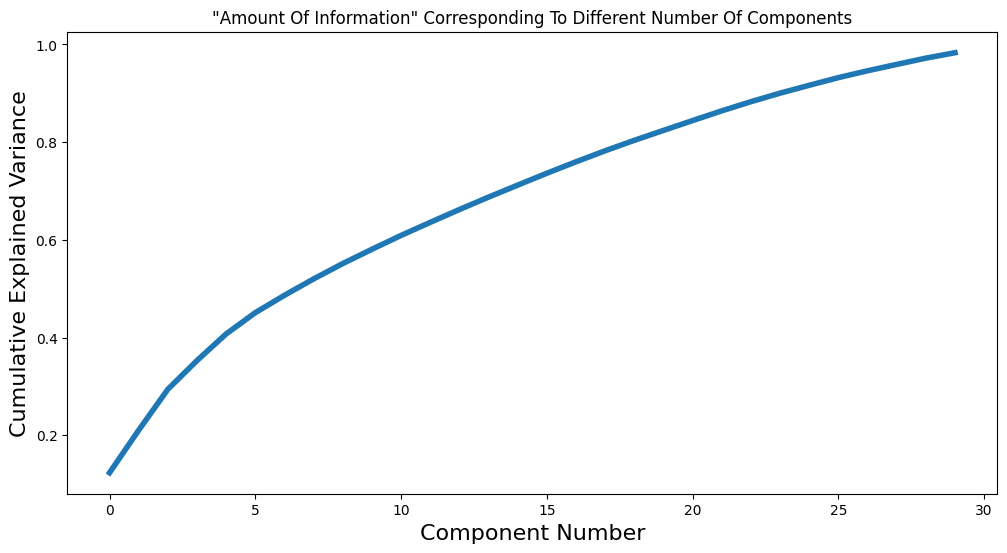

In [858]:
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_),lw=4)
plt.xlabel('Component Number',fontsize=16)
plt.ylabel('Cumulative Explained Variance',fontsize=16)
plt.title('"Amount Of Information" Corresponding To Different Number Of Components')
plt.show()

<b style="font-size:2rem;">When is feature engineering a nice-to-have option, and when is it a must-have?</b>
<p style="font-size:1.7rem;">When we have enough data, that a portion of that data (excluding the target column) has enough correlation with the target column (which is very dependent on the task) we probably do not neeed feature engineering and we can interpolate or predict the value of the target column according to the data. But if there isn't enough correlation between the target column and the rest of the data (which again is very circumstantial) we need features that have enough correlation with the target column, which we can obtain using feature engineering.</p>

<b style="font-size:3rem;">Web Scraping</b>
<p style="font-size:1.7rem;">In the following section we extract the data about “Samand”s that have been manufactured after 1385 from <a href="https://bama.ir">bama website.</a></p>

In [859]:
num_cars_to_fetch = 50
num_cars_per_page = 10
cars = []

for page_index in range(0,np.int64(np.ceil(num_cars_to_fetch/num_cars_per_page))):
    res = requests.get(f"https://bama.ir/cad/api/search?vehicle=samand&yearFrom=1385-2006&pageIndex={page_index+1}&pageSize={num_cars_per_page}")
    for ad in res.json()["data"]["ads"]:
        car = {
            "mileage": ad["detail"]["mileage"],
            "price": ad["price"]["price"],
            "color": ad["detail"]["color"],
            "year": ad["detail"]["year"],
            "transmission": ad["detail"]["transmission"],
            "description": ad["detail"]["description"]
        }
        cars.append(car)
    if len(cars) >= num_cars_to_fetch:
        break

cars_df = pd.DataFrame(data=cars)
cars_df.to_excel("Cars.xlsx")